## Helper functions

In [1]:
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import MinMaxScaler
from src.core.fingerprints import Fingerprints
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

THR = 0.99

def visualize_target(df: pd.DataFrame, target_name: str, n_bins: int = 50) -> None:
    fig, (ax_box, ax_hist) = plt.subplots(
        2, sharex=True, gridspec_kw={"height_ratios": (.15, .85)}, figsize=(10, 8)
    )
    sns.boxplot(x=df[target_name], ax=ax_box, orient='h')
    ax_box.set(xlabel='')
    sns.histplot(df[target_name], bins=n_bins, kde=True, ax=ax_hist)

    ax_box.set_title(f'Distribution of {target_name}')
    plt.show()

def print_stats(df: pd.DataFrame, target_name: str) -> None:
    print(f"Mean: {df[target_name].mean():.4f}")
    print(f"Median: {df[target_name].median():.4f}")
    print(f"Standard Deviation: {df[target_name].std():.4f}")
    print(f"Minimum: {df[target_name].min():.4f}")
    print(f"Maximum: {df[target_name].max():.4f}")

def ecfp_features(smiles_name: str, target_name: str, df: pd.DataFrame, threshold: float = 0.99) -> pd.DataFrame:
    names = ['ecfp']
    params = {
        'ecfp': {'radius': 2, 'size': 1024, 'count': True},
    }
    fingerprints, f_names = Fingerprints().apply(
        smiles=df[smiles_name].tolist(),
        names=names,
        **params
    )
    df_fingerprints = pd.DataFrame(fingerprints, columns=f_names)
    scaler = MinMaxScaler()
    df_features_scaled = scaler.fit_transform(df_fingerprints)
    selector = VarianceThreshold(threshold=1 - threshold)
    selector.fit(df_features_scaled)
    df_fingerprints = df_fingerprints.iloc[:, selector.get_support(indices=True)]
    df_fingerprints[target_name] = df[target_name].values
    df_fingerprints[smiles_name] = df[smiles_name].values
    return df_fingerprints

def check_nans(df: pd.DataFrame) -> None:
    nan_counts = df.isna().sum()
    print("NaN counts per column:")
    print(nan_counts)

def remove_nans(df: pd.DataFrame) -> pd.DataFrame:
    return df.dropna().reset_index(drop=True)

def remove_incorrect_molecules(df: pd.DataFrame, smiles_col: str) -> pd.DataFrame:
    from rdkit import Chem
    mols = [Chem.MolFromSmiles(smi) for smi in df[smiles_col]]
    valid_indices = [i for i, m in enumerate(mols) if m is not None]
    return df.iloc[valid_indices].reset_index(drop=True)

def remove_duplicates(df: pd.DataFrame, smiles_col: str) -> pd.DataFrame:
    return df.drop_duplicates(subset=[smiles_col]).reset_index(drop=True)

def remove_outliers(df: pd.DataFrame, target_col: str) -> pd.DataFrame:
    mean = df[target_col].mean()
    std = df[target_col].std()
    lower_bound = mean - 3 * std
    upper_bound = mean + 3 * std
    return df[(df[target_col] >= lower_bound) & (df[target_col] <= upper_bound)].reset_index(drop=True)


## CNOHF

In [2]:
df_cnohf = pd.read_excel('../data/raw/cnohf.xlsx')
df_cnohf

,Name,short name,note,group,density g/cm3,gas-phase formation enthalpy,sublimation enthalpy,"heat of explosion (kJ/g , but note sensitivity data did not report units, and values are different?)",detonation velocity (km/s),detonation pressure (GPa),Gurney energy,h50 (obs),Reference,SMILES
0,"4-picrylamino-1,2,3-triazole",NaN,NaN,Unst. (N2 loss),1.719,382.3,185.0,5.05,7.203,22.380,4794.0,103.0,"Mathieu, 2017",n1n[nH]cc1Nc1c(cc(cc1N(=O)=O)N(=O)=O)N(=O)=O
1,"1-(3',5'-dinitrophenyl)-4-nitro-1,2,3-triazole",NaN,NaN,Unst. (N2 loss),1.701,367.0,162.0,5.27,7.131,21.790,4623.0,56.0,"Mathieu, 2017",n1c(cn(n1)c1cc(cc(c1)N(=O)=O)N(=O)=O)N(=O)=O
2,"1-(3',4'-dinitrophenyl)-4-nitro-1,2,3-triazole",NaN,NaN,Unst. (N2 loss),1.701,403.8,162.0,5.40,7.175,22.060,4739.0,51.0,"Mathieu, 2017",n1c(cn(n1)c1ccc(c(c1)N(=O)=O)N(=O)=O)N(=O)=O
3,"4,6-dinitro-1-picryl-benzotriazole",NaN,NaN,Unst. (N2 loss),1.783,478.4,240.0,5.46,7.415,24.250,5016.0,40.0,"Mathieu, 2017",c1(c2c(cc(c1)N(=O)=O)n(nn2)c1c(cc(cc1N(=O)=O)N...
4,"1-Picryl-5,7-dinitrobenzotriazole",BTX,NaN,Unst. (N2 loss),1.783,455.3,240.0,5.41,7.396,24.130,4966.0,40.0,"Mathieu, 2017",c1c(cc(c2c1nnn2c1c(cc(cc1N(=O)=O)N(=O)=O)N(=O)...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
411,ZZZMUC,NaN,TNT - with isolated molecule refcode,TNT,1.654,NaN,NaN,NaN,7.179,20.053,NaN,NaN,"Huang et al., 2013",Cc1c(cc(cc1N(=O)=O)N(=O)=O)N(=O)=O
412,CHATC3N,NaN,"Note: this one is cut off at the bottom, but f...",Butterfly,1.952,NaN,NaN,NaN,8.650,33.443,NaN,NaN,"Huang et al., 2013",[H]C2([H])N(N(=O)=O)C1([H])OC(=O)OC1([H])N2N(=...
413,SRIP25,NaN,Note the discrepancy between the chemical form...,Pyrazole,1.725,NaN,NaN,NaN,9.384,33.831,NaN,NaN,"Huang et al., 2013",[H]ON([H])n1cnc(N([H])[H])n1
414,CLCPI,NaN,"""Me"" is short for a methyl - a carbon with 3 ...",Butterfly,1.756,NaN,NaN,NaN,8.074,27.188,NaN,NaN,"Huang et al., 2013",[H]C([H])([H])[O]COC2C(N(=O)=O)C1C(N(N(=O)=O)C...


In [3]:
check_nans(df_cnohf)

NaN counts per column:
Name                                                                                                       0
short name                                                                                               360
note                                                                                                     411
group                                                                                                      0
density g/cm3                                                                                              0
gas-phase formation enthalpy                                                                             109
sublimation enthalpy                                                                                     109
heat of explosion (kJ/g , but note sensitivity data did not report units, and values are different?)     109
detonation velocity (km/s)                                                                               

In [4]:
df_cnohf = df_cnohf[['SMILES', 'detonation velocity (km/s)']]
df_cnohf.rename(columns={'SMILES': 'smiles', 'detonation velocity (km/s)': 'detonation_velocity'}, inplace=True)
df_cnohf.head()

/tmp/ipykernel_39498/2471812562.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cnohf.rename(columns={'SMILES': 'smiles', 'detonation velocity (km/s)': 'detonation_velocity'}, inplace=True)


,smiles,detonation_velocity
0,n1n[nH]cc1Nc1c(cc(cc1N(=O)=O)N(=O)=O)N(=O)=O,7.203
1,n1c(cn(n1)c1cc(cc(c1)N(=O)=O)N(=O)=O)N(=O)=O,7.131
2,n1c(cn(n1)c1ccc(c(c1)N(=O)=O)N(=O)=O)N(=O)=O,7.175
3,c1(c2c(cc(c1)N(=O)=O)n(nn2)c1c(cc(cc1N(=O)=O)N...,7.415
4,c1c(cc(c2c1nnn2c1c(cc(cc1N(=O)=O)N(=O)=O)N(=O)...,7.396


In [5]:
df_cnohf = remove_nans(df_cnohf)
df_cnohf = remove_duplicates(df_cnohf, 'smiles')
df_cnohf = remove_incorrect_molecules(df_cnohf, 'smiles')
len(df_cnohf)

414

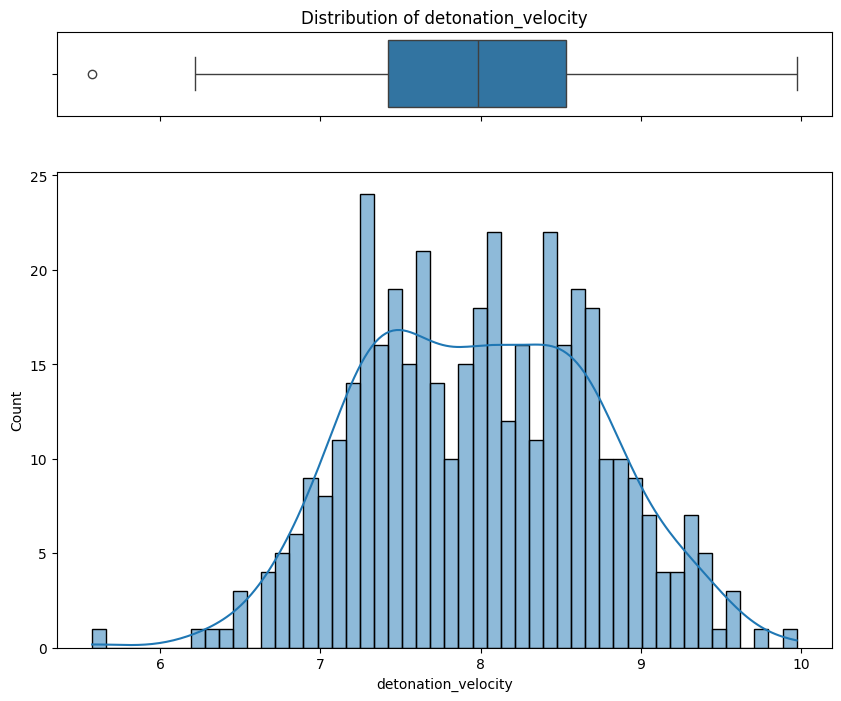

Mean: 7.9876
Median: 7.9815
Standard Deviation: 0.7242
Minimum: 5.5760
Maximum: 9.9720


In [6]:
visualize_target(df_cnohf, 'detonation_velocity')
print_stats(df_cnohf, 'detonation_velocity')

In [7]:
df_cnohf = remove_outliers(df_cnohf, 'detonation_velocity')
len(df_cnohf)

413

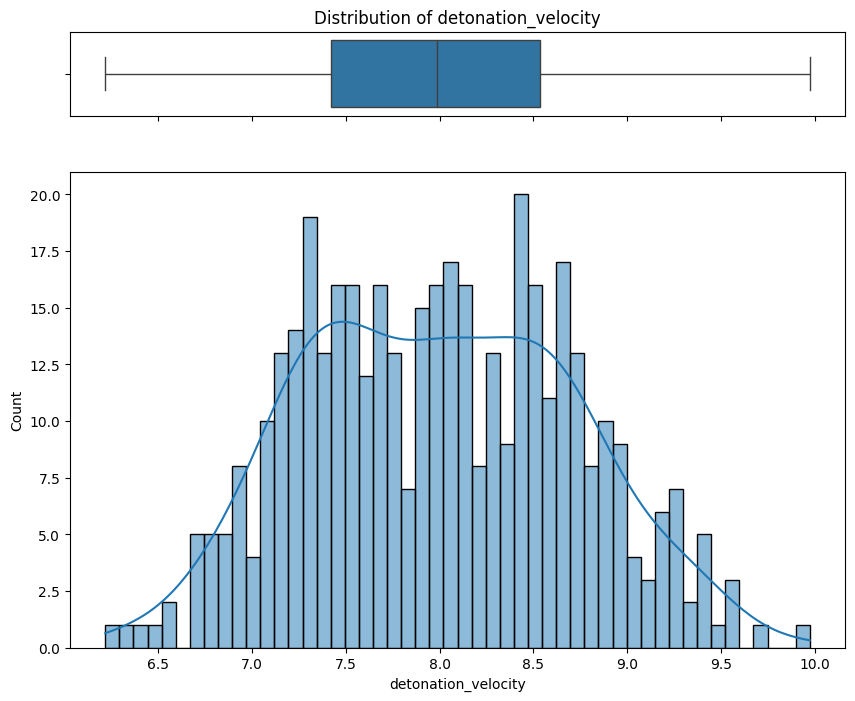

Mean: 7.9935
Median: 7.9870
Standard Deviation: 0.7153
Minimum: 6.2200
Maximum: 9.9720


In [8]:
visualize_target(df_cnohf, 'detonation_velocity')
print_stats(df_cnohf, 'detonation_velocity')

In [9]:
df_cnohf_ecfp = ecfp_features('smiles', 'detonation_velocity', df_cnohf, threshold=THR)
df_cnohf_ecfp.head()

,ecfp_feature_13,ecfp_feature_31,ecfp_feature_33,ecfp_feature_36,ecfp_feature_37,ecfp_feature_60,ecfp_feature_62,ecfp_feature_80,ecfp_feature_81,ecfp_feature_90,...,ecfp_feature_970,ecfp_feature_971,ecfp_feature_976,ecfp_feature_980,ecfp_feature_987,ecfp_feature_1004,ecfp_feature_1013,ecfp_feature_1019,detonation_velocity,smiles
0,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,7.203,n1n[nH]cc1Nc1c(cc(cc1N(=O)=O)N(=O)=O)N(=O)=O
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,7.131,n1c(cn(n1)c1cc(cc(c1)N(=O)=O)N(=O)=O)N(=O)=O
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,7.175,n1c(cn(n1)c1ccc(c(c1)N(=O)=O)N(=O)=O)N(=O)=O
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,7.415,c1(c2c(cc(c1)N(=O)=O)n(nn2)c1c(cc(cc1N(=O)=O)N...
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,7.396,c1c(cc(c2c1nnn2c1c(cc(cc1N(=O)=O)N(=O)=O)N(=O)...


In [50]:
(df_cnohf_ecfp['detonation_velocity'].max() - df_cnohf_ecfp['detonation_velocity'].min()) * 1/10

np.float64(0.3752)

In [10]:
df_cnohf_ecfp.to_csv('../data/cnohf_data/cnohf_ecfp.csv', index=False)

## FreeSolv

In [11]:
df_freesolv = pd.read_csv('../data/raw/freesolv.csv')
df_freesolv

,iupac,smiles,expt,calc
0,"4-methoxy-N,N-dimethyl-benzamide",CN(C)C(=O)c1ccc(cc1)OC,-11.01,-9.625
1,methanesulfonyl chloride,CS(=O)(=O)Cl,-4.87,-6.219
2,3-methylbut-1-ene,CC(C)C=C,1.83,2.452
3,2-ethylpyrazine,CCc1cnccn1,-5.45,-5.809
4,heptan-1-ol,CCCCCCCO,-4.21,-2.917
...,...,...,...,...
637,methyl octanoate,CCCCCCCC(=O)OC,-2.04,-3.035
638,pyrrolidine,C1CCNC1,-5.48,-4.278
639,4-hydroxybenzaldehyde,c1cc(ccc1C=O)O,-8.83,-10.050
640,1-chloroheptane,CCCCCCCCl,0.29,1.467


In [12]:
check_nans(df_freesolv)

NaN counts per column:
iupac     0
smiles    0
expt      0
calc      0
dtype: int64


In [13]:
df_freesolv = df_freesolv[['smiles', 'expt']]
df_freesolv.rename(columns={'expt': 'target'}, inplace=True)
df_freesolv.head()

/tmp/ipykernel_39498/3188747000.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_freesolv.rename(columns={'expt': 'target'}, inplace=True)


,smiles,target
0,CN(C)C(=O)c1ccc(cc1)OC,-11.01
1,CS(=O)(=O)Cl,-4.87
2,CC(C)C=C,1.83
3,CCc1cnccn1,-5.45
4,CCCCCCCO,-4.21


In [14]:
df_freesolv = remove_nans(df_freesolv)
df_freecolv = remove_duplicates(df_freesolv, 'smiles')
df_freesolv = remove_incorrect_molecules(df_freesolv, 'smiles')
len(df_freesolv)

642

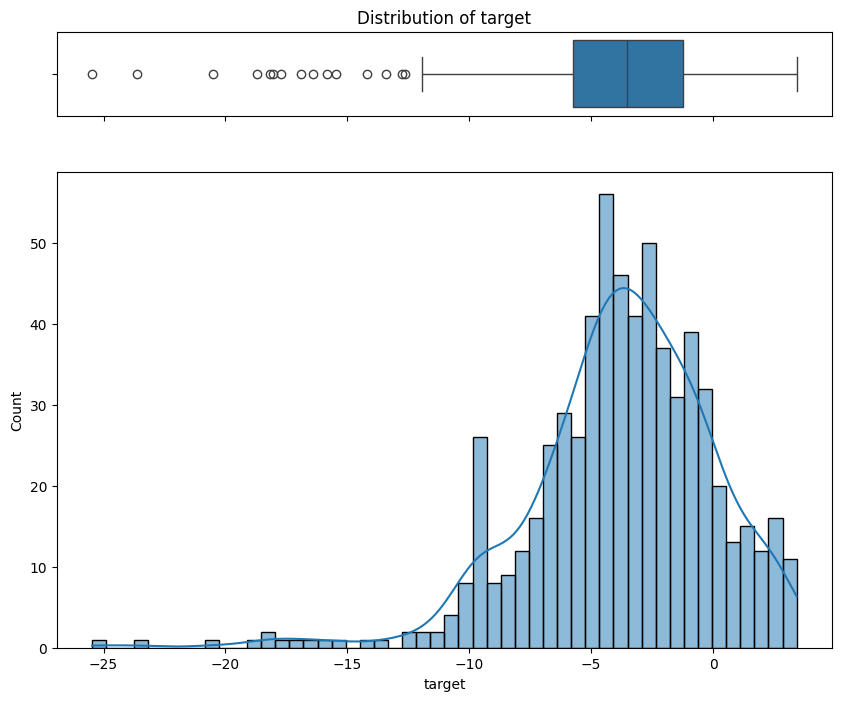

Mean: -3.8030
Median: -3.5300
Standard Deviation: 3.8478
Minimum: -25.4700
Maximum: 3.4300


In [15]:
visualize_target(df_freesolv, 'target')
print_stats(df_freesolv, 'target')

In [16]:
df_freesolv = remove_outliers(df_freesolv, 'target')
len(df_freesolv)

631

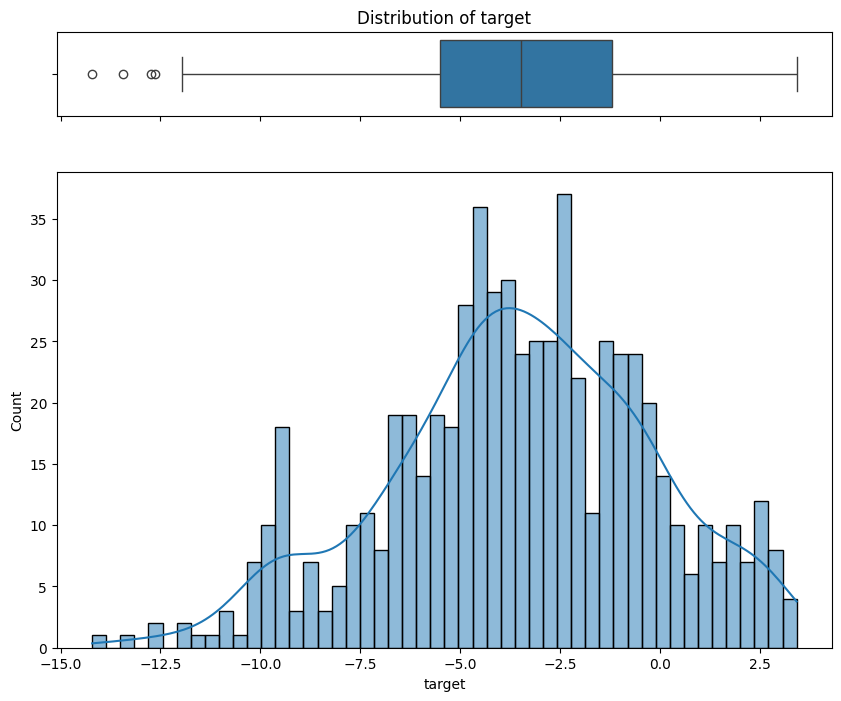

Mean: -3.5413
Median: -3.4800
Standard Deviation: 3.3016
Minimum: -14.2100
Maximum: 3.4300


In [17]:
visualize_target(df_freesolv, 'target')
print_stats(df_freesolv, 'target')

In [18]:
df_freesolv_ecfp = ecfp_features('smiles', 'target', df_freesolv, threshold=THR)
df_freesolv_ecfp.head()

,ecfp_feature_1,ecfp_feature_13,ecfp_feature_15,ecfp_feature_19,ecfp_feature_21,ecfp_feature_22,ecfp_feature_33,ecfp_feature_42,ecfp_feature_58,ecfp_feature_64,...,ecfp_feature_955,ecfp_feature_971,ecfp_feature_975,ecfp_feature_981,ecfp_feature_997,ecfp_feature_1004,ecfp_feature_1009,ecfp_feature_1017,target,smiles
0,0,0,0,0,0,0,3,0,0,0,...,0,0,0,0,0,0,0,0,-11.01,CN(C)C(=O)c1ccc(cc1)OC
1,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,-4.87,CS(=O)(=O)Cl
2,1,0,0,0,0,0,2,0,0,0,...,0,0,0,0,0,0,0,0,1.83,CC(C)C=C
3,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,-5.45,CCc1cnccn1
4,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,-4.21,CCCCCCCO


In [51]:
(df_freesolv_ecfp['target'].max() - df_freesolv_ecfp['target'].min()) * 1/10

np.float64(1.764)

In [19]:
df_freesolv_ecfp.to_csv('../data/freesolv_data/freesolv_ecfp.csv', index=False)

## Photoswitches

In [20]:
df_photo = pd.read_csv('../data/raw/photoswitches.csv')
df_photo

,Unnamed: 0,SMILES,rate of thermal isomerisation from Z-E in s-1,Solvent used for thermal isomerisation rates,Z PhotoStationaryState,E PhotoStationaryState,E isomer pi-pi* wavelength in nm,Extinction,E isomer n-pi* wavelength in nm,Extinction coefficient in M-1 cm-1,...,TPSSh/6-31G** DFT Z isomer pi-pi* wavelength in nm,TPSSh/6-31G** DFT Z isomer n-pi* wavelength in nm,CAM-B3LYP/6-31G** DFT E isomer pi-pi* wavelength in nm,CAM-B3LYP/6-31G** DFT E isomer n-pi* wavelength in nm,CAM-B3LYP/6-31G** DFT Z isomer pi-pi* wavelength in nm,CAM-B3LYP/6-31G** DFT Z isomer n-pi* wavelength in nm,BHLYP/6-31G* DFT E isomer pi-pi* wavelength in nm,BHLYP/6-31G* DFT E isomer n-pi* wavelength in nm,BHLYP/6-31G* Z isomer pi-pi* wavelength in nm,BHLYP/6-31G* DFT Z isomer n-pi* wavelength in nm
0,0,C[N]1N=NC(=N1)N=NC2=CC=CC=C2,2.100000e-07,MeCN,76.0,72.0,310.0,1.67,442.0,0.0373,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,C[N]1C=NC(=N1)N=NC2=CC=CC=C2,3.800000e-07,MeCN,90.0,84.0,310.0,1.87,438.0,0.0505,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,C[N]1C=CC(=N1)N=NC2=CC=CC=C2,1.100000e-07,MeCN,98.0,97.0,320.0,1.46,425.0,0.0778,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,C[N]1C=C(C)C(=N1)N=NC2=CC=CC=C2,1.500000e-06,MeCN,96.0,87.0,325.0,1.74,428.0,0.0612,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,C[N]1C=C(C=N1)N=NC2=CC=CC=C2,7.600000e-09,MeCN,98.0,70.0,328.0,1.66,417.0,0.0640,...,295.0,410.0,305.0,427.0,256.0,401.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
400,400,OC%38=C%39N=CC=CC%39=C(/N=N/C%40=NC%41=CC(C)=C...,NaN,NaN,NaN,NaN,456.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
401,401,OC%42=C%43N=CC=CC%43=C(/N=N/C%44=NC%45=CC=CC=C...,NaN,NaN,NaN,NaN,437.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
402,402,N#CC1C(SC(/N=N/C2=NC(C=CC([N+]([O-])=O)=C3)=C3...,NaN,NaN,NaN,NaN,545.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
403,403,N#Cc5c(c6ccc(Cl)cc6)c(/N=N/C7=NC(C=CC([N+]([O-...,NaN,NaN,NaN,NaN,535.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
check_nans(df_photo)

NaN counts per column:
Unnamed: 0                                                  0
SMILES                                                      0
rate of thermal isomerisation from Z-E in s-1             330
Solvent used for thermal isomerisation rates              353
Z PhotoStationaryState                                    329
E PhotoStationaryState                                    331
E isomer pi-pi* wavelength in nm                           13
Extinction                                                372
E isomer n-pi* wavelength in nm                           264
Extinction coefficient in M-1 cm-1                        379
Z isomer pi-pi* wavelength in nm                          312
Extinction.1                                              393
Z isomer n-pi* wavelength in nm                           282
Extinction coefficient in M-1 cm-1.1                      382
Wiberg index                                              390
E-Z irradiation wavelength in nm               

In [22]:
df_photo = df_photo[['SMILES', 'E isomer pi-pi* wavelength in nm']]
df_photo.rename(columns={'SMILES': 'smiles', 'E isomer pi-pi* wavelength in nm': 'e_isomer_pi_pi'}, inplace=True)
df_photo.head()

/tmp/ipykernel_39498/2022833898.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_photo.rename(columns={'SMILES': 'smiles', 'E isomer pi-pi* wavelength in nm': 'e_isomer_pi_pi'}, inplace=True)


,smiles,e_isomer_pi_pi
0,C[N]1N=NC(=N1)N=NC2=CC=CC=C2,310.0
1,C[N]1C=NC(=N1)N=NC2=CC=CC=C2,310.0
2,C[N]1C=CC(=N1)N=NC2=CC=CC=C2,320.0
3,C[N]1C=C(C)C(=N1)N=NC2=CC=CC=C2,325.0
4,C[N]1C=C(C=N1)N=NC2=CC=CC=C2,328.0


In [23]:
df_photo = remove_nans(df_photo)
df_photo = remove_duplicates(df_photo, 'smiles')
df_photo = remove_incorrect_molecules(df_photo, 'smiles')
len(df_photo)

391

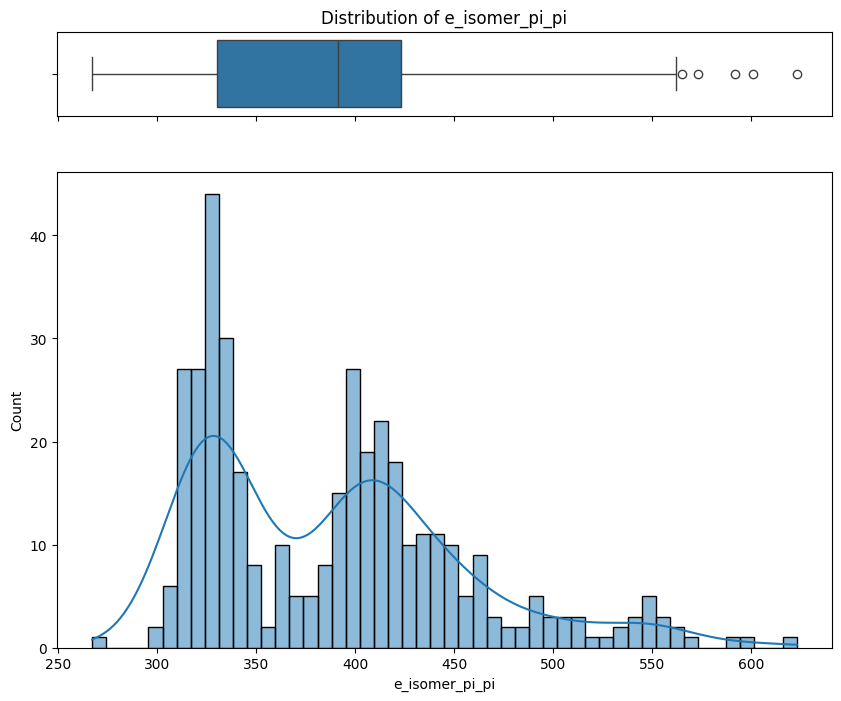

Mean: 388.3274
Median: 391.0000
Standard Deviation: 65.9704
Minimum: 267.0000
Maximum: 623.0000


In [24]:
visualize_target(df_photo, 'e_isomer_pi_pi')
print_stats(df_photo, 'e_isomer_pi_pi')

In [25]:
df_photo = remove_outliers(df_photo, 'e_isomer_pi_pi')
len(df_photo)

388

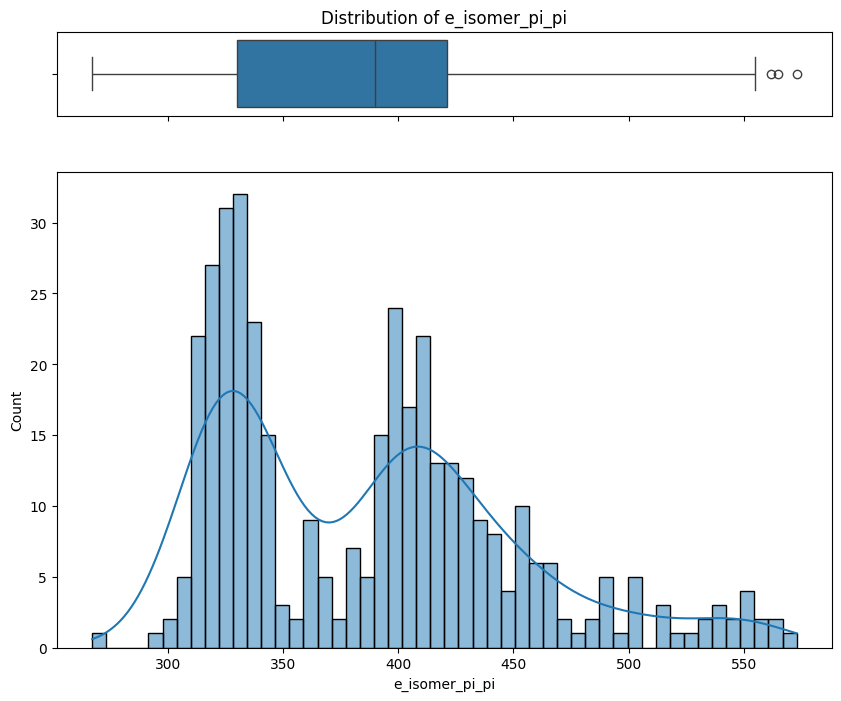

Mean: 386.6495
Median: 390.0000
Standard Deviation: 63.3769
Minimum: 267.0000
Maximum: 573.0000


In [26]:
visualize_target(df_photo, 'e_isomer_pi_pi')
print_stats(df_photo, 'e_isomer_pi_pi')

In [27]:
df_photo_ecfp = ecfp_features('smiles', 'e_isomer_pi_pi', df_photo, threshold=THR)
df_photo_ecfp

,ecfp_feature_12,ecfp_feature_14,ecfp_feature_15,ecfp_feature_18,ecfp_feature_19,ecfp_feature_23,ecfp_feature_28,ecfp_feature_33,ecfp_feature_34,ecfp_feature_43,...,ecfp_feature_993,ecfp_feature_994,ecfp_feature_999,ecfp_feature_1000,ecfp_feature_1006,ecfp_feature_1013,ecfp_feature_1017,ecfp_feature_1023,e_isomer_pi_pi,smiles
0,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,310.0,C[N]1N=NC(=N1)N=NC2=CC=CC=C2
1,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,310.0,C[N]1C=NC(=N1)N=NC2=CC=CC=C2
2,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,320.0,C[N]1C=CC(=N1)N=NC2=CC=CC=C2
3,0,0,0,0,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,325.0,C[N]1C=C(C)C(=N1)N=NC2=CC=CC=C2
4,0,0,0,0,0,0,0,1,0,1,...,0,0,0,0,0,0,0,0,328.0,C[N]1C=C(C=N1)N=NC2=CC=CC=C2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
383,0,0,0,1,1,0,0,2,0,0,...,0,0,0,0,0,0,0,0,456.0,OC%38=C%39N=CC=CC%39=C(/N=N/C%40=NC%41=CC(C)=C...
384,0,0,0,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,437.0,OC%42=C%43N=CC=CC%43=C(/N=N/C%44=NC%45=CC=CC=C...
385,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,545.0,N#CC1C(SC(/N=N/C2=NC(C=CC([N+]([O-])=O)=C3)=C3...
386,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,1,0,535.0,N#Cc5c(c6ccc(Cl)cc6)c(/N=N/C7=NC(C=CC([N+]([O-...


In [52]:
(df_photo_ecfp['e_isomer_pi_pi'].max() - df_photo_ecfp['e_isomer_pi_pi'].min()) * 1/10

np.float64(30.6)

In [28]:
df_photo_ecfp.to_csv('../data/photoswitch_data/photoswitch_ecfp.csv', index=False)

## Polymers

In [29]:
df_poly = pd.read_csv('../data/raw/polymers.csv')
df_poly

,Nº,Name,Tg/K,SMILES
0,1,Poly(benzyl acrylate),279,C=CC(=O)OCc1ccccc1
1,2,Poly(4-biphenyl acrylate),383,C=CC(=O)Oc2ccc(c1ccccc1)cc2
2,3,Poly(butyl acrylate),219,CCCCOC(=O)C=C
3,4,Poly(sec-butyl acrylate),250,CC(OC(=O)C=C)CC
4,5,Poly(2-tertbutylphenyl acrylate),345,C=CC(=O)Oc1ccccc1C(C)(C)C
...,...,...,...,...
191,214,Poly(dodecano-12-lactam),313,NCCCCCCCCCCCC(=O)O
192,215,Poly(decano-10-lactam),315,NCCCCCCCCCC(=O)O
193,216,Poly(octano-8-lactam),324,O=C1CCCCCCCN1
194,217,Poly(6-aminohexanoic acid),324,O=C1CCCCCN1


In [30]:
check_nans(df_poly)

NaN counts per column:
Nº        0
Name      0
Tg/K      0
SMILES    0
dtype: int64


In [31]:
df_poly = df_poly[['SMILES', 'Tg/K']]
df_poly.rename(columns={'SMILES': 'smiles', 'Tg/K': 'Tg'}, inplace=True)
df_poly.head()

/tmp/ipykernel_39498/4214275142.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_poly.rename(columns={'SMILES': 'smiles', 'Tg/K': 'Tg'}, inplace=True)


,smiles,Tg
0,C=CC(=O)OCc1ccccc1,279
1,C=CC(=O)Oc2ccc(c1ccccc1)cc2,383
2,CCCCOC(=O)C=C,219
3,CC(OC(=O)C=C)CC,250
4,C=CC(=O)Oc1ccccc1C(C)(C)C,345


In [32]:
df_poly = remove_nans(df_poly)
df_poly = remove_duplicates(df_poly, 'smiles')
df_poly = remove_incorrect_molecules(df_poly, 'smiles')
len(df_poly)

[21:35:02] Explicit valence for atom # 10 Cl, 3, is greater than permitted
[21:35:02] SMILES Parse Error: syntax error while parsing: O=
[21:35:02] SMILES Parse Error: check for mistakes around position 2:
[21:35:02] O=
[21:35:02] ~^
[21:35:02] SMILES Parse Error: Failed parsing SMILES 'O=' for input: 'O='


194

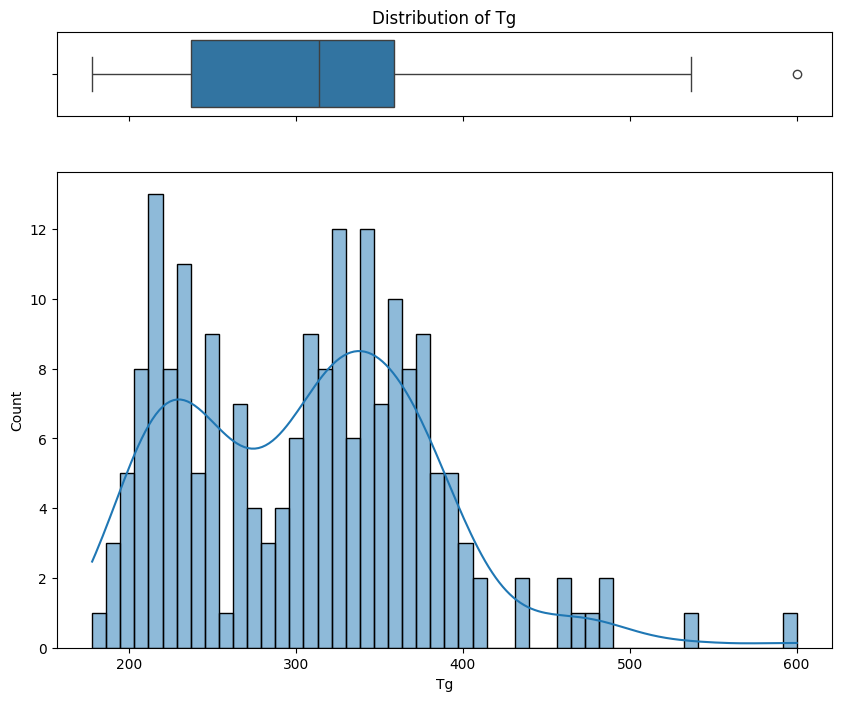

Mean: 306.7577
Median: 314.0000
Standard Deviation: 74.5577
Minimum: 178.0000
Maximum: 600.0000


In [33]:
visualize_target(df_poly, 'Tg')
print_stats(df_poly, 'Tg')

In [34]:
df_poly = remove_outliers(df_poly, 'Tg')
len(df_poly)

192

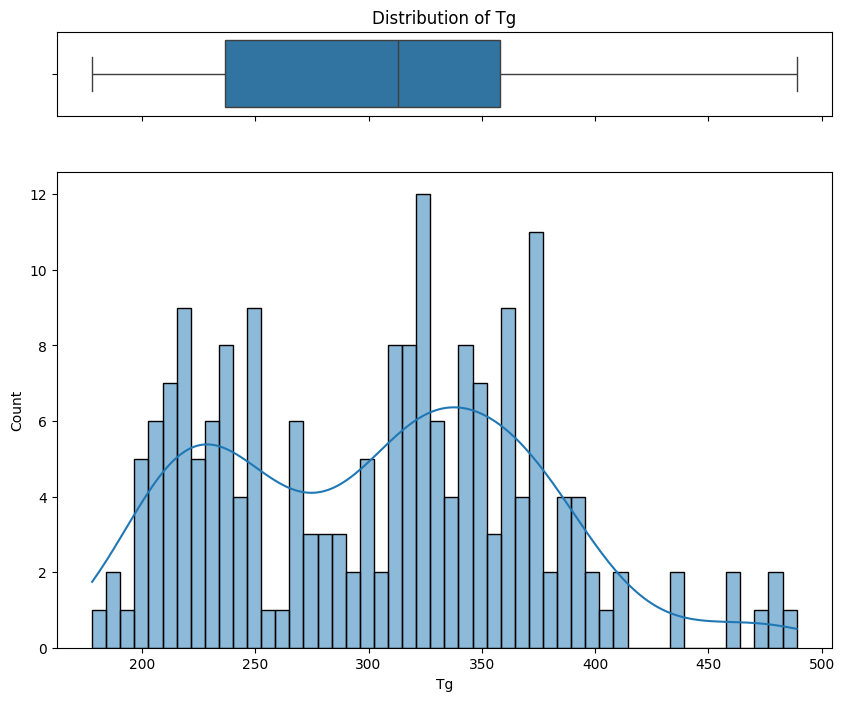

Mean: 304.0312
Median: 313.0000
Standard Deviation: 69.8700
Minimum: 178.0000
Maximum: 489.0000


In [35]:
visualize_target(df_poly, 'Tg')
print_stats(df_poly, 'Tg')

In [36]:
df_poly_ecfp = ecfp_features('smiles', 'Tg', df_poly, threshold=THR)
df_poly_ecfp.head()

,ecfp_feature_1,ecfp_feature_4,ecfp_feature_8,ecfp_feature_9,ecfp_feature_10,ecfp_feature_13,ecfp_feature_15,ecfp_feature_17,ecfp_feature_21,ecfp_feature_25,...,ecfp_feature_1002,ecfp_feature_1005,ecfp_feature_1009,ecfp_feature_1012,ecfp_feature_1017,ecfp_feature_1018,ecfp_feature_1019,ecfp_feature_1022,Tg,smiles
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,279,C=CC(=O)OCc1ccccc1
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,383,C=CC(=O)Oc2ccc(c1ccccc1)cc2
2,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,219,CCCCOC(=O)C=C
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,250,CC(OC(=O)C=C)CC
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,345,C=CC(=O)Oc1ccccc1C(C)(C)C


In [54]:
(df_poly_ecfp['Tg'].max() - df_poly_ecfp['Tg'].min()) * 1/10

np.float64(31.1)

In [37]:
df_poly_ecfp.to_csv('../data/polymers_data/polymers_ecfp.csv', index=False)

## Redox

In [40]:
redox_smiles = pd.read_csv('../data/raw/redox_smiles.csv')
redox_target = pd.read_csv('../data/raw/redox_pbe0_dG.csv')
df_redox = redox_smiles.merge(redox_target, on='runs')
df_redox

,runs,smiles,dEred,dEox,dGred,dGox
0,10-2-pyrrolidinylethyl-7b_n,c1ccc2c(c1)N(c1c(S2)cccc1)CCN1CCCC1,13.336,148.276,8.555,147.349
1,10-acetyl-7b_n,c1ccc2c(c1)N(c1c(S2)cccc1)C(=O)C,7.480,164.367,2.649,163.147
2,10-benzoylpheno-7b_n,c1ccc2c(c1)N(c1c(S2)cccc1)C(=O)c1ccccc1,-15.474,157.681,-19.280,156.685
3,10-carboxaldehyde-7b_n,c1ccc2c(c1)N(c1c(S2)cccc1)C=O,6.840,169.064,2.184,168.746
4,10-methyl-7b_n,c1ccc2c(c1)N(c1c(S2)cccc1)C,14.890,151.249,8.899,151.361
...,...,...,...,...,...,...
154,i47di-2-met-3-phenyl_n,C1=CC(=O)c2c(C1=O)cn(c2c1ccccc1)C,-33.493,178.317,-34.986,177.946
155,indigodisulfonate_2a,c1(ccc2c(c1)C(=O)/C(=C/1\Nc3c(C1=O)cc(cc3)S(=O...,53.628,55.311,51.835,55.176
156,methoxatine_n,C1(=O)C(=O)c2c(c3c1cc(cc3C(=O)O)C(=O)O)[nH]c(c...,-58.876,195.958,-60.349,193.711
157,mitomycinC_n,C1(=C(C(=O)C2=C(C1=O)[C@@H]([C@@]1(N2C[C@@H]2[...,-36.098,162.240,-36.958,161.417


In [41]:
check_nans(df_redox)

NaN counts per column:
runs      0
smiles    0
dEred     0
dEox      0
dGred     0
dGox      0
dtype: int64


In [42]:
df_redox = df_redox[['smiles', 'dGox']]
df_redox.head()

,smiles,dGox
0,c1ccc2c(c1)N(c1c(S2)cccc1)CCN1CCCC1,147.349
1,c1ccc2c(c1)N(c1c(S2)cccc1)C(=O)C,163.147
2,c1ccc2c(c1)N(c1c(S2)cccc1)C(=O)c1ccccc1,156.685
3,c1ccc2c(c1)N(c1c(S2)cccc1)C=O,168.746
4,c1ccc2c(c1)N(c1c(S2)cccc1)C,151.361


In [43]:
df_redox = remove_nans(df_redox)
df_redox = remove_duplicates(df_redox, 'smiles')
df_redox = remove_incorrect_molecules(df_redox, 'smiles')
len(df_redox)

159

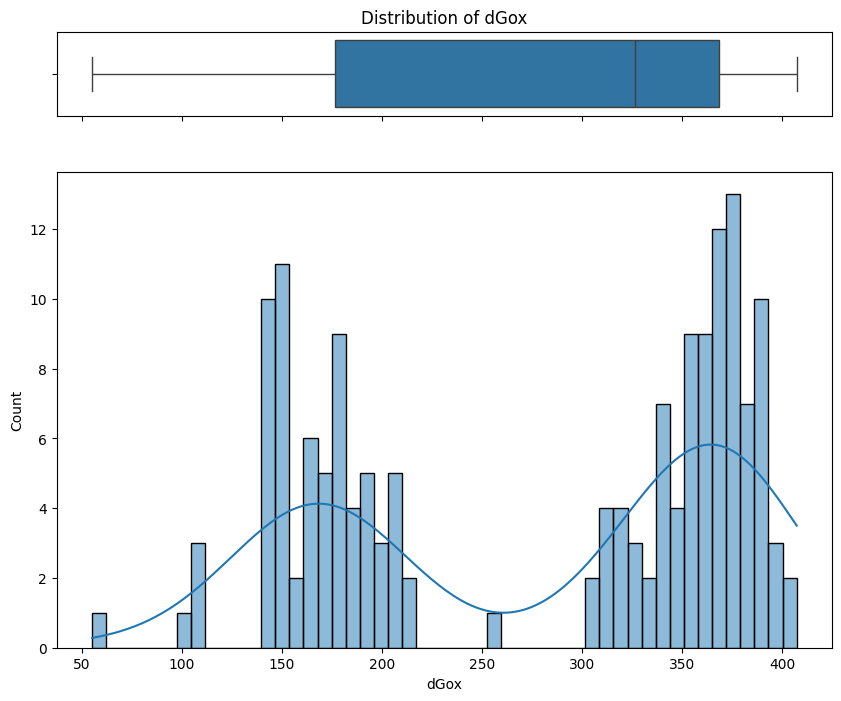

Mean: 278.1533
Median: 326.4090
Standard Deviation: 100.3459
Minimum: 55.1760
Maximum: 407.3570


In [44]:
visualize_target(df_redox, 'dGox')
print_stats(df_redox, 'dGox')

In [45]:
df_redox = remove_outliers(df_redox, 'dGox')
len(df_redox)

159

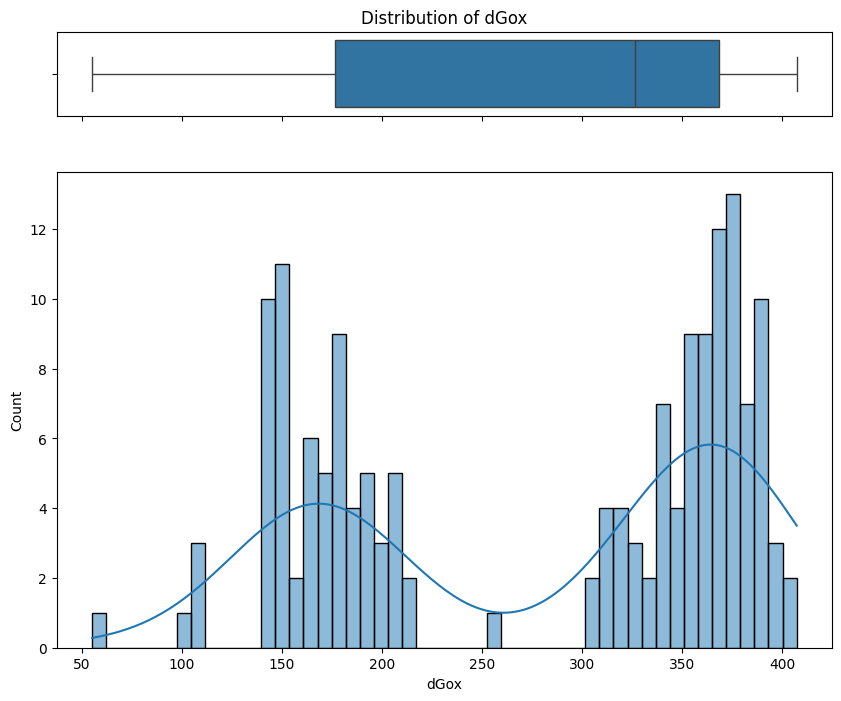

Mean: 278.1533
Median: 326.4090
Standard Deviation: 100.3459
Minimum: 55.1760
Maximum: 407.3570


In [47]:
visualize_target(df_redox, 'dGox')
print_stats(df_redox, 'dGox')

In [48]:
df_redox_ecfp = ecfp_features('smiles', 'dGox', df_redox, threshold=THR)
df_redox_ecfp.head()

,ecfp_feature_1,ecfp_feature_4,ecfp_feature_7,ecfp_feature_11,ecfp_feature_12,ecfp_feature_15,ecfp_feature_21,ecfp_feature_28,ecfp_feature_29,ecfp_feature_30,...,ecfp_feature_982,ecfp_feature_984,ecfp_feature_987,ecfp_feature_1005,ecfp_feature_1013,ecfp_feature_1017,ecfp_feature_1019,ecfp_feature_1020,dGox,smiles
0,0,2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,147.349,c1ccc2c(c1)N(c1c(S2)cccc1)CCN1CCCC1
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,1,163.147,c1ccc2c(c1)N(c1c(S2)cccc1)C(=O)C
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,156.685,c1ccc2c(c1)N(c1c(S2)cccc1)C(=O)c1ccccc1
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,168.746,c1ccc2c(c1)N(c1c(S2)cccc1)C=O
4,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,1,151.361,c1ccc2c(c1)N(c1c(S2)cccc1)C


In [55]:
(df_redox_ecfp['dGox'].max() - df_redox_ecfp['dGox'].min()) * 1/10

np.float64(35.21810000000001)

In [49]:
df_redox_ecfp.to_csv('../data/redox_data/redox_ecfp.csv', index=False)